In [1]:
import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
plt.rcParams["figure.figsize"] = (14, 6)

plt.rcParams["font.size"] = 12

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

PROCESSED_DATA_PATH = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "cleaned_covid_data.csv"
)

print(PROCESSED_DATA_PATH)

C:\Users\roshi\Downloads\covid19-data-analysis-visualization-main\covid19-data-analysis-visualization-main\data\processed\cleaned_covid_data.csv


In [4]:
df = pd.read_csv(PROCESSED_DATA_PATH)

print("Processed Dataset Loaded Successfully")

Processed Dataset Loaded Successfully


In [5]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print(df["date"].head())

0   2019-12-31
1   2019-12-31
2   2019-12-31
3   2019-12-31
4   2019-12-31
Name: date, dtype: datetime64[ns]


In [6]:
print(df.shape)

df.head()

(44785, 49)


,iso_code,continent,country,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,life_expectancy,human_development_index,new_vaccinations,total_vaccinations,total_cases_country,total_deaths_country,total_vaccinations_country,mortality_rate,daily_growth_rate,rolling_avg_cases
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,64.83,0.498,0,0,0.0,0.0,0,0.0,0.0,0.0
1,IRL,Europe,Ireland,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,82.30,0.938,0,0,0.0,0.0,0,0.0,0.0,0.0
2,IRQ,Asia,Iraq,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,70.60,0.685,0,0,0.0,0.0,0,0.0,0.0,0.0
3,IRN,Asia,Iran,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,76.68,0.798,0,0,0.0,0.0,0,0.0,0.0,0.0
4,IDN,Asia,Indonesia,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,71.72,0.694,0,0,0.0,0.0,0,0.0,0.0,0.0


In [7]:
global_trend_df = (
    df.groupby("date")[
        [
            "new_cases",
            "new_deaths",
            "total_vaccinations"
        ]
    ]
    .sum()
    .reset_index()
)

global_trend_df.head()

,date,new_cases,new_deaths,total_vaccinations
0,2019-12-31,54.0,0.0,0
1,2020-01-01,0.0,0.0,0
2,2020-01-02,0.0,0.0,0
3,2020-01-03,34.0,0.0,0
4,2020-01-04,0.0,0.0,0


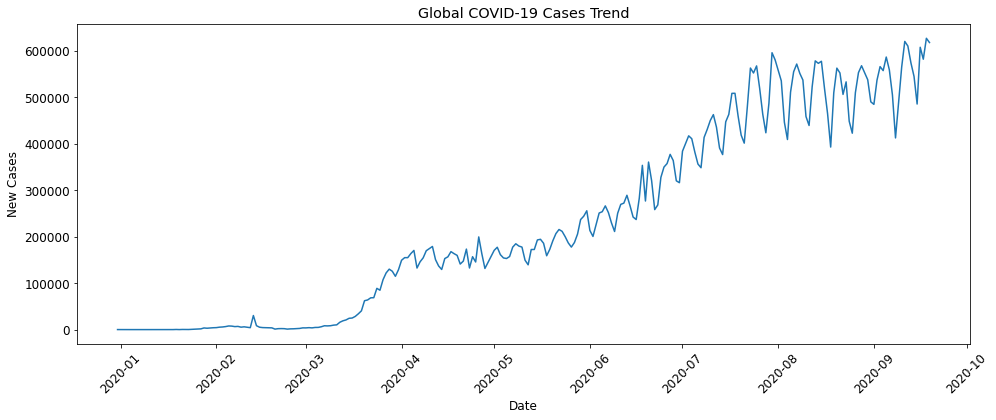

In [8]:
plt.figure()

plt.plot(
    global_trend_df["date"].values,
    global_trend_df["new_cases"].values
)

plt.title("Global COVID-19 Cases Trend")

plt.xlabel("Date")

plt.ylabel("New Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

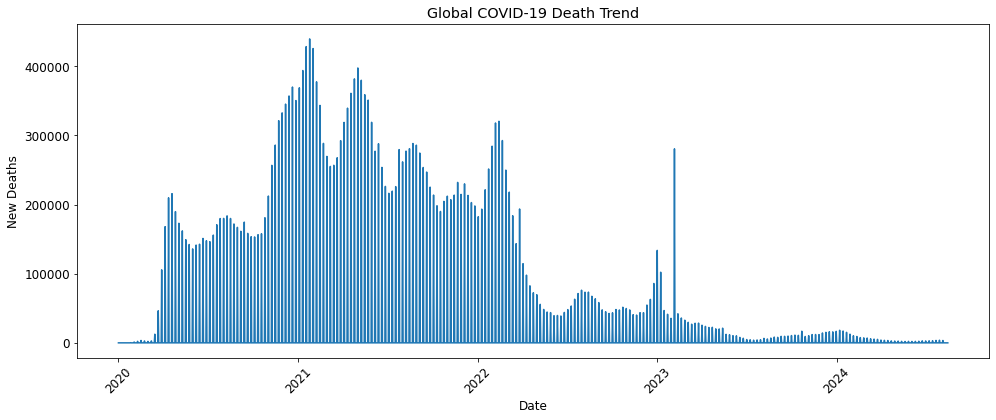

In [9]:
plt.figure()

plt.plot(
    global_trend_df["date"].values,
    global_trend_df["new_deaths"].values
)

plt.title("Global COVID-19 Death Trend")

plt.xlabel("Date")

plt.ylabel("New Deaths")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

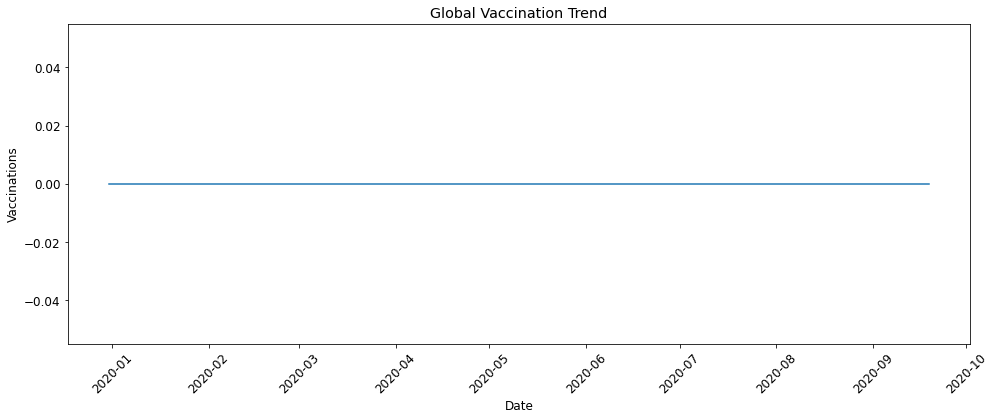

In [10]:
plt.figure()

plt.plot(
    global_trend_df["date"].values,
    global_trend_df["total_vaccinations"].values
)

plt.title("Global Vaccination Trend")

plt.xlabel("Date")

plt.ylabel("Vaccinations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [11]:
top_cases = (
    df.groupby("country")["new_cases"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cases

country
World            30540446.0
United States     6724667.0
India             5308014.0
Brazil            4495183.0
Russia            1091186.0
Peru               756412.0
Colombia           750471.0
Mexico             688954.0
South Africa       657627.0
Spain              641125.0
Name: new_cases, dtype: float64

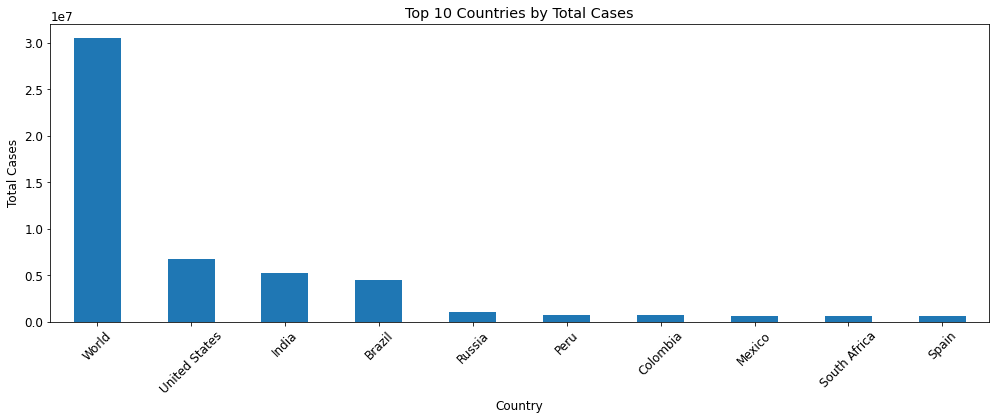

In [12]:
plt.figure()

top_cases.plot(kind="bar")

plt.title("Top 10 Countries by Total Cases")

plt.xlabel("Country")

plt.ylabel("Total Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [13]:
top_deaths = (
    df.groupby("country")["new_deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_deaths

country
World             952724.0
United States     198589.0
Brazil            135793.0
India              85619.0
Mexico             72803.0
United Kingdom     41732.0
Italy              35699.0
Spain              32415.0
Peru               31283.0
France             31249.0
Name: new_deaths, dtype: float64

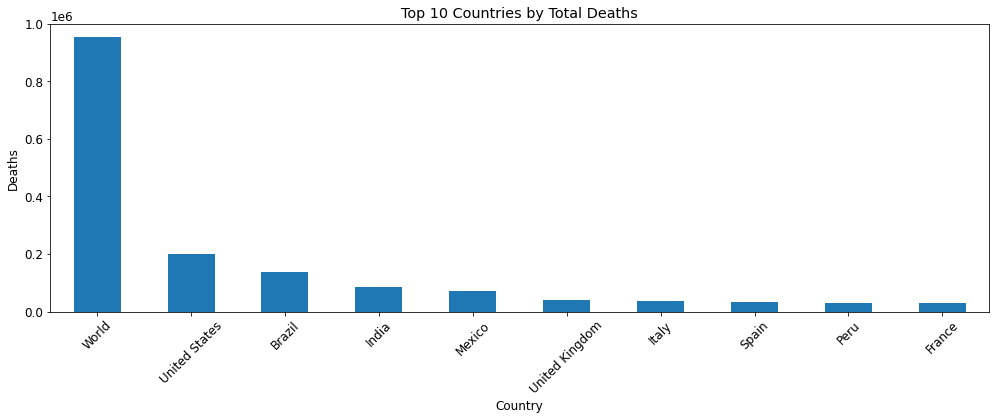

In [14]:
plt.figure()

top_deaths.plot(kind="bar")

plt.title("Top 10 Countries by Total Deaths")

plt.xlabel("Country")

plt.ylabel("Deaths")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [15]:
top_vaccinations = (
    df.groupby("country")["total_vaccinations"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_vaccinations

country
Afghanistan      0
Mozambique       0
Namibia          0
Nepal            0
Netherlands      0
New Caledonia    0
New Zealand      0
Nicaragua        0
Niger            0
Nigeria          0
Name: total_vaccinations, dtype: int64

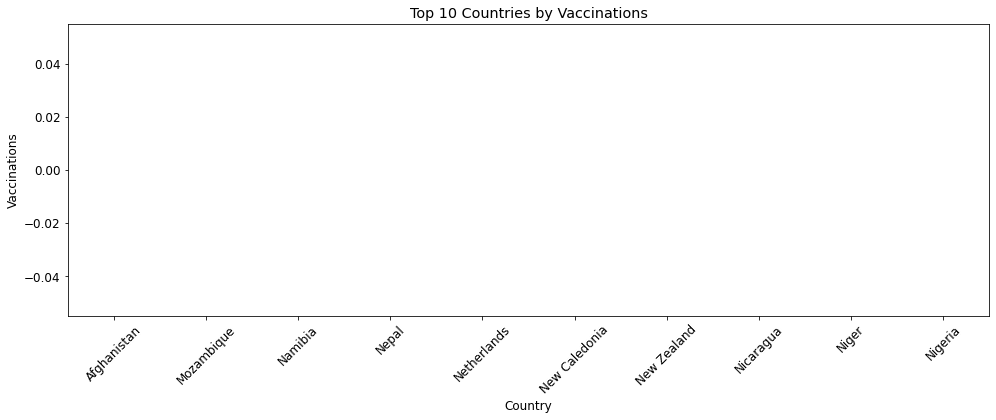

In [16]:
plt.figure()

top_vaccinations.plot(kind="bar")

plt.title("Top 10 Countries by Vaccinations")

plt.xlabel("Country")

plt.ylabel("Vaccinations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [17]:
latest_date = df["date"].max()

latest_df = df[
    df["date"] == latest_date
]

latest_df.head()

,iso_code,continent,country,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,life_expectancy,human_development_index,new_vaccinations,total_vaccinations,total_cases_country,total_deaths_country,total_vaccinations_country,mortality_rate,daily_growth_rate,rolling_avg_cases
44575,DZA,Africa,Algeria,2020-09-19,49413.0,219.0,237.286,1659.0,5.0,8.571,...,76.88,0.754,0,0,49413.0,1659.0,0,3.357416,-3.947368,237.285714
44576,ARM,Asia,Armenia,2020-09-19,46910.0,239.0,201.000,926.0,1.0,2.429,...,75.09,0.755,0,0,46910.0,926.0,0,1.973993,-18.983051,201.000000
44577,ALB,Europe,Albania,2020-09-19,12073.0,125.0,150.286,353.0,5.0,3.714,...,78.57,0.785,0,0,12073.0,353.0,0,2.923880,-5.303030,150.285714
44578,ARG,South America,Argentina,2020-09-19,601700.0,12701.0,11073.571,12491.0,262.0,213.857,...,76.67,0.825,0,0,601700.0,12491.0,0,2.075951,8.797327,11073.571429
44579,AGO,Africa,Angola,2020-09-19,3789.0,40.0,81.714,144.0,0.0,2.000,...,61.15,0.581,0,0,3789.0,144.0,0,3.800475,-77.777778,81.714286


In [18]:
hotspots = latest_df.sort_values(
    by="new_cases",
    ascending=False
).head(10)

hotspots[
    [
        "country",
        "new_cases",
        "new_deaths"
    ]
]

,country,new_cases,new_deaths
44714,World,309076.0,5947.0
44743,India,93337.0,1247.0
44670,United States,50209.0,956.0
44725,Brazil,39797.0,858.0
44770,France,13215.0,154.0
44578,Argentina,12701.0,262.0
44692,Colombia,6526.0,185.0
44635,Peru,6314.0,137.0
44666,Russia,5905.0,134.0
44632,Mexico,4841.0,624.0


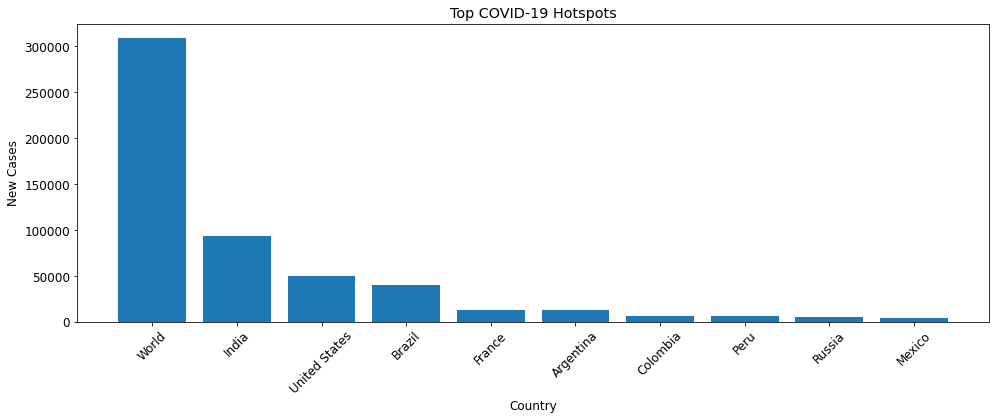

In [19]:
plt.bar(
    hotspots["country"].values,
    hotspots["new_cases"].values
)

plt.title("Top COVID-19 Hotspots")

plt.xlabel("Country")

plt.ylabel("New Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [20]:
mortality_df = (
    df.groupby("country")[
        [
            "new_cases",
            "new_deaths"
        ]
    ]
    .sum()
    .reset_index()
)

mortality_df["mortality_rate"] = np.where(
    mortality_df["new_cases"] > 0,
    (
        mortality_df["new_deaths"]
        / mortality_df["new_cases"]
    ) * 100,
    0
)

mortality_df.head()

,country,new_cases,new_deaths,mortality_rate
0,Afghanistan,38919.0,1437.0,3.692284
1,Albania,12073.0,353.0,2.923880
2,Algeria,49413.0,1659.0,3.357416
3,Andorra,1564.0,53.0,3.388747
4,Angola,3789.0,144.0,3.800475


In [21]:
top_mortality = mortality_df.sort_values(
    by="mortality_rate",
    ascending=False
).head(10)

top_mortality[
    [
        "country",
        "mortality_rate"
    ]
]

,country,mortality_rate
209,Yemen,28.903162
98,Italy,12.098075
199,United Kingdom,10.813192
126,Mexico,10.567179
18,Belgium,9.981417
57,Ecuador,8.097902
101,Jersey,8.020050
131,Montserrat,7.692308
68,France,7.276313
96,Isle Of Man,7.079646


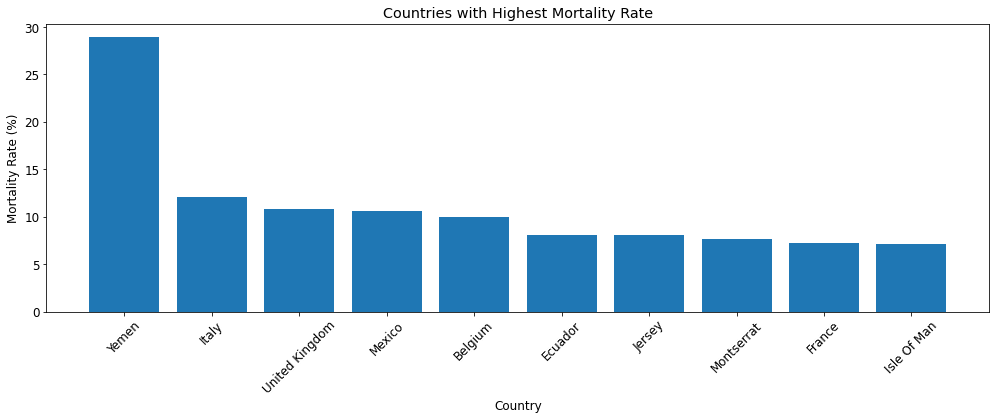

In [22]:
plt.figure()

plt.bar(
    top_mortality["country"].values,
    top_mortality["mortality_rate"].values
)

plt.title("Countries with Highest Mortality Rate")

plt.xlabel("Country")

plt.ylabel("Mortality Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [23]:
rolling_cases = (
    global_trend_df["new_cases"]
    .rolling(window=7, min_periods=1)
    .mean()
)

rolling_cases.head()

0    54.0
1    27.0
2    18.0
3    22.0
4    17.6
Name: new_cases, dtype: float64

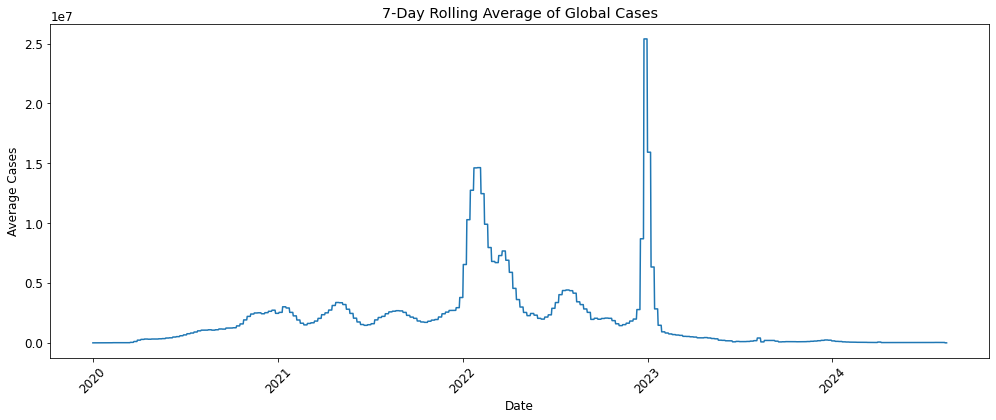

In [24]:
plt.figure()

plt.plot(
    global_trend_df["date"].values,
    rolling_cases.values
)

plt.title("7-Day Rolling Average of Global Cases")

plt.xlabel("Date")

plt.ylabel("Average Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [24]:
vaccination_growth = (
    global_trend_df["total_vaccinations"]
    .pct_change()
    .fillna(0)
) * 100

vaccination_growth.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: total_vaccinations, dtype: float64

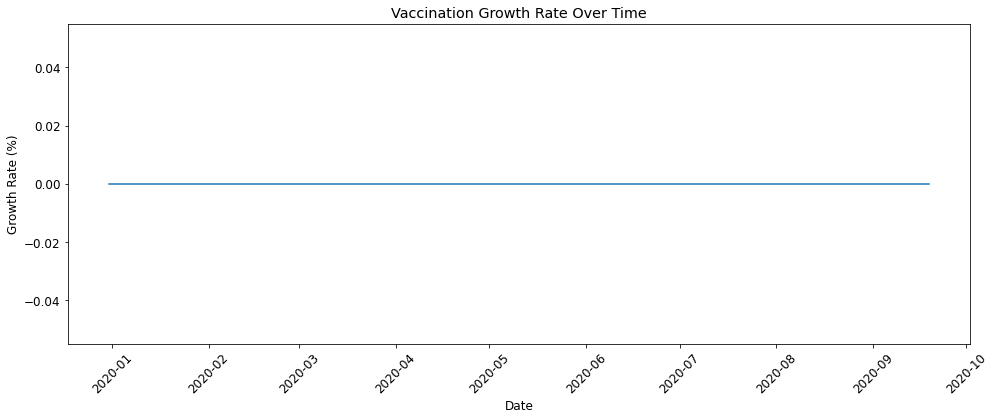

In [25]:
plt.figure()

plt.plot(
    global_trend_df["date"].values,
    vaccination_growth.values
)

plt.title("Vaccination Growth Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Growth Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

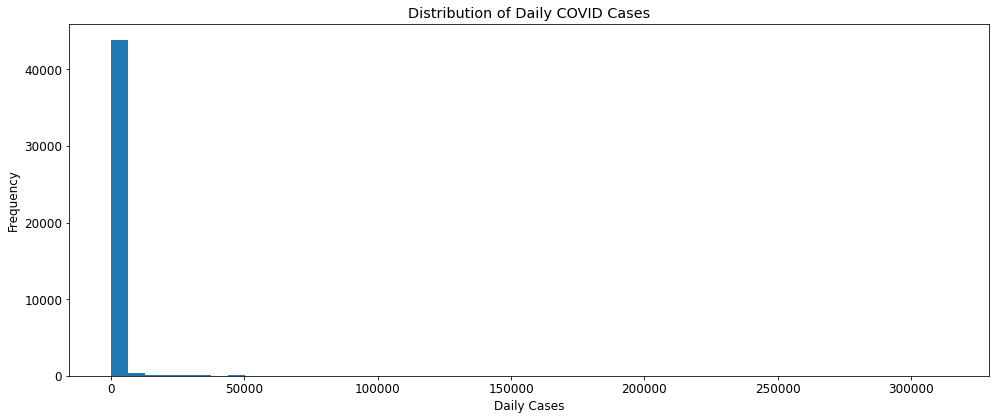

In [26]:
plt.figure()

plt.hist(
    df["new_cases"],
    bins=50
)

plt.title("Distribution of Daily COVID Cases")

plt.xlabel("Daily Cases")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

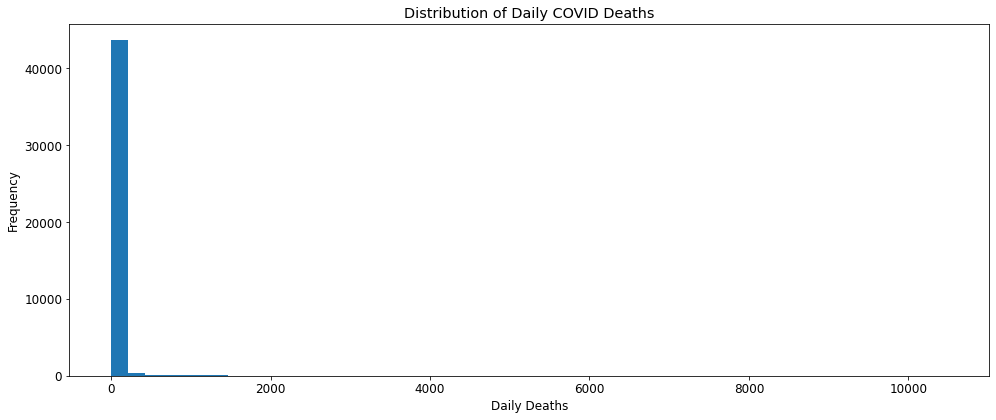

In [27]:
plt.figure()

plt.hist(
    df["new_deaths"],
    bins=50
)

plt.title("Distribution of Daily COVID Deaths")

plt.xlabel("Daily Deaths")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

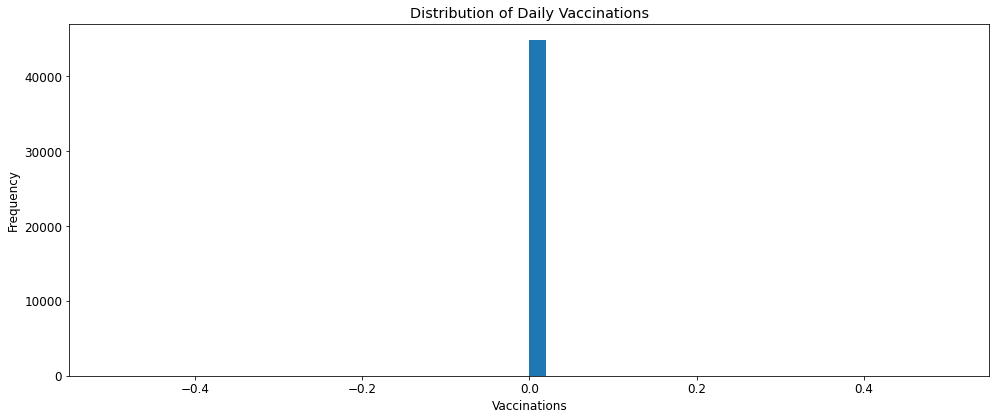

In [28]:
plt.figure()

plt.hist(
    df["total_vaccinations"],
    bins=50
)

plt.title("Distribution of Daily Vaccinations")

plt.xlabel("Vaccinations")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [29]:
india_df = df[
    df["country"] == "India"
]

india_df.head()

,iso_code,continent,country,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,life_expectancy,human_development_index,new_vaccinations,total_vaccinations,total_cases_country,total_deaths_country,total_vaccinations_country,mortality_rate,daily_growth_rate,rolling_avg_cases
5,IND,Asia,India,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,69.66,0.64,0,0,0.0,0.0,0,0.0,0.0,0.0
75,IND,Asia,India,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,69.66,0.64,0,0,0.0,0.0,0,0.0,0.0,0.0
198,IND,Asia,India,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,69.66,0.64,0,0,0.0,0.0,0,0.0,0.0,0.0
259,IND,Asia,India,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,69.66,0.64,0,0,0.0,0.0,0,0.0,0.0,0.0
303,IND,Asia,India,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,69.66,0.64,0,0,0.0,0.0,0,0.0,0.0,0.0


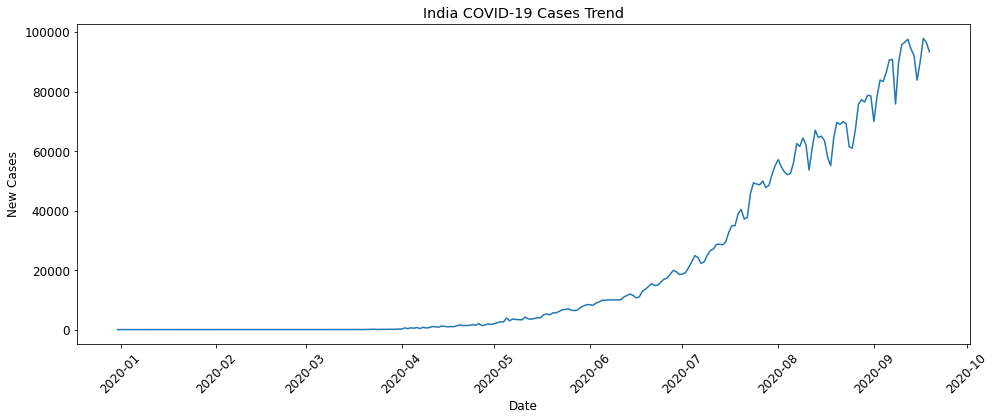

In [30]:
plt.figure()

plt.plot(
    india_df["date"].values,
    india_df["new_cases"].values
)

plt.title("India COVID-19 Cases Trend")

plt.xlabel("Date")

plt.ylabel("New Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

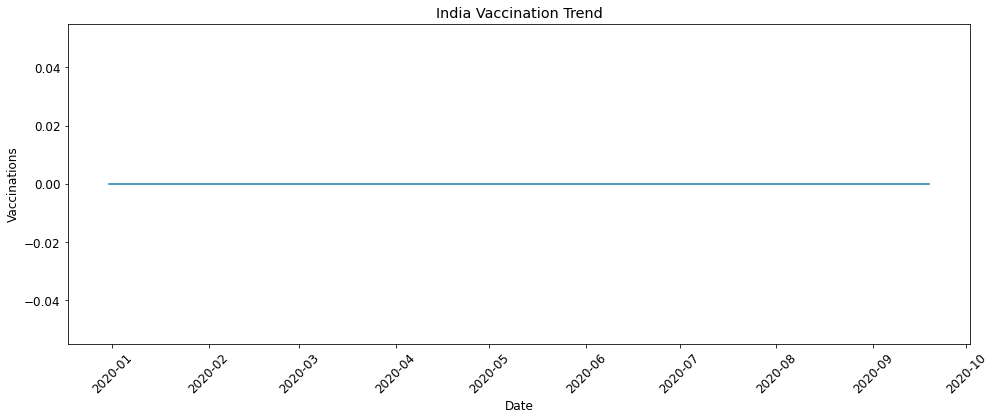

In [31]:
plt.figure()

plt.plot(
    india_df["date"].values,
    india_df["total_vaccinations"].values
)

plt.title("India Vaccination Trend")

plt.xlabel("Date")

plt.ylabel("Vaccinations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [32]:
print("Visual Analysis Completed Successfully")

Visual Analysis Completed Successfully
